# NBA Salary Prediction — Evaluation

Goal: Evaluate the winning model — Lasso Regression.
- Residual analysis
- Actual vs predicted salary chart
- Most over and underpaid players per the model
- SHAP feature importance

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap
from pathlib import Path
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
DATA_DIR = Path('../data')

X_train = pd.read_pickle(DATA_DIR / 'X_train.pkl')
X_test  = pd.read_pickle(DATA_DIR / 'X_test.pkl')
y_train = pd.read_pickle(DATA_DIR / 'y_train.pkl')
y_test  = pd.read_pickle(DATA_DIR / 'y_test.pkl')
player_info = pd.read_pickle(DATA_DIR / 'player_info.pkl')

with open(DATA_DIR / 'final_model.pkl', 'rb') as f:
    lasso = pickle.load(f)

test_pred_log  = lasso.predict(X_test)
test_pred_usd  = np.exp(test_pred_log)
test_actual_usd = np.exp(y_test)

print("Data and model loaded successfully")
print(f"Test set: {X_test.shape[0]} players")

Data and model loaded successfully
Test set: 82 players


## Visual 1: Residual analysis
Residuals = actual minus predicted salary.
A good model has residuals randomly scattered around zero 
with no clear pattern.

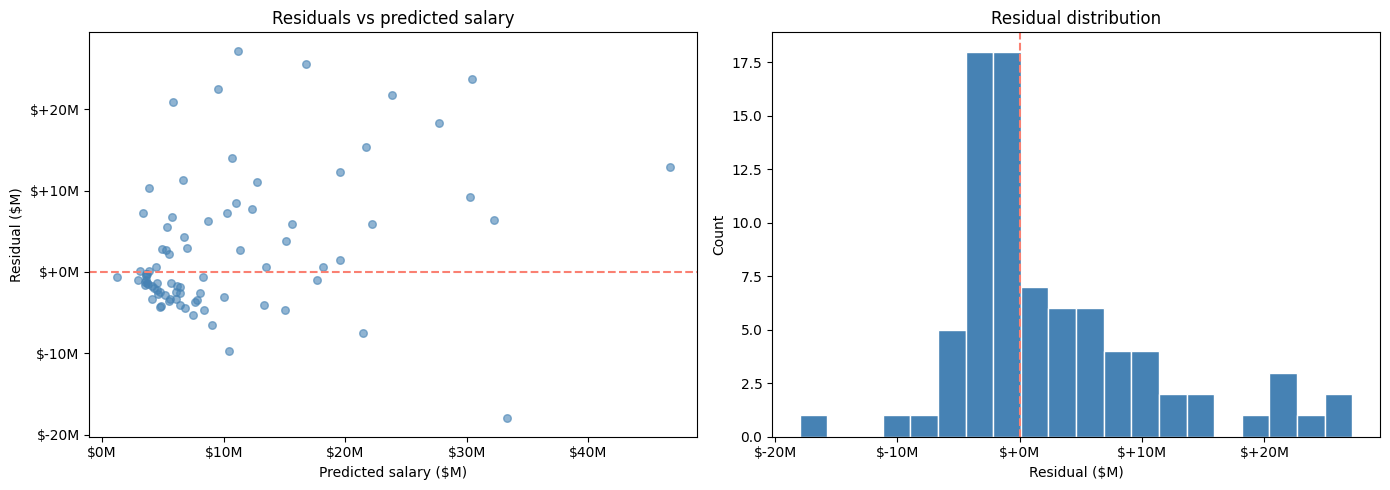

Mean residual:   $+2.6M
Median residual: $-0.5M
Std residual:    $8.4M


In [7]:
residuals = test_actual_usd - test_pred_usd

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — residuals vs predicted
axes[0].scatter(test_pred_usd / 1e6, residuals / 1e6,
                alpha=0.6, color='steelblue', s=30)
axes[0].axhline(y=0, color='salmon', linewidth=1.5, linestyle='--')
axes[0].set_title('Residuals vs predicted salary')
axes[0].set_xlabel('Predicted salary ($M)')
axes[0].set_ylabel('Residual ($M)')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:.0f}M'))
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'${y:+.0f}M'))

# Right — residual distribution
axes[1].hist(residuals / 1e6, bins=20, 
             color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='salmon', linewidth=1.5, linestyle='--')
axes[1].set_title('Residual distribution')
axes[1].set_xlabel('Residual ($M)')
axes[1].set_ylabel('Count')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:+.0f}M'))

plt.tight_layout()
plt.savefig('../outputs/08_residuals.png')
plt.show()

print(f"Mean residual:   ${residuals.mean()/1e6:+.1f}M")
print(f"Median residual: ${residuals.median()/1e6:+.1f}M")
print(f"Std residual:    ${residuals.std()/1e6:.1f}M")

## Finding — residual analysis

Left chart (residuals vs predicted):
- Points scatter around zero at low predicted salaries ($0-15M) 
  — model performs well for most players
- At higher predicted salaries ($20M+) residuals skew positive — 
  the model underpredicts high earners consistently
- No clear curve pattern — relationship is reasonably linear

Right chart (residual distribution):
- Distribution is roughly centered near zero with a slight 
  right tail
- Mean residual: +$2.6M — model slightly underpredicts on average
- Median residual: -$0.5M — median close to zero, mean pulled 
  up by a few large positive residuals
- Std: $8.4M — consistent with our $8.7M test RMSE

The positive skew in residuals at high salaries confirms our 
EDA finding — max contract players are systematically 
underpredicted because their salaries reflect reputation and 
market timing that stats cannot capture.

## Visual 2: Actual vs predicted salary

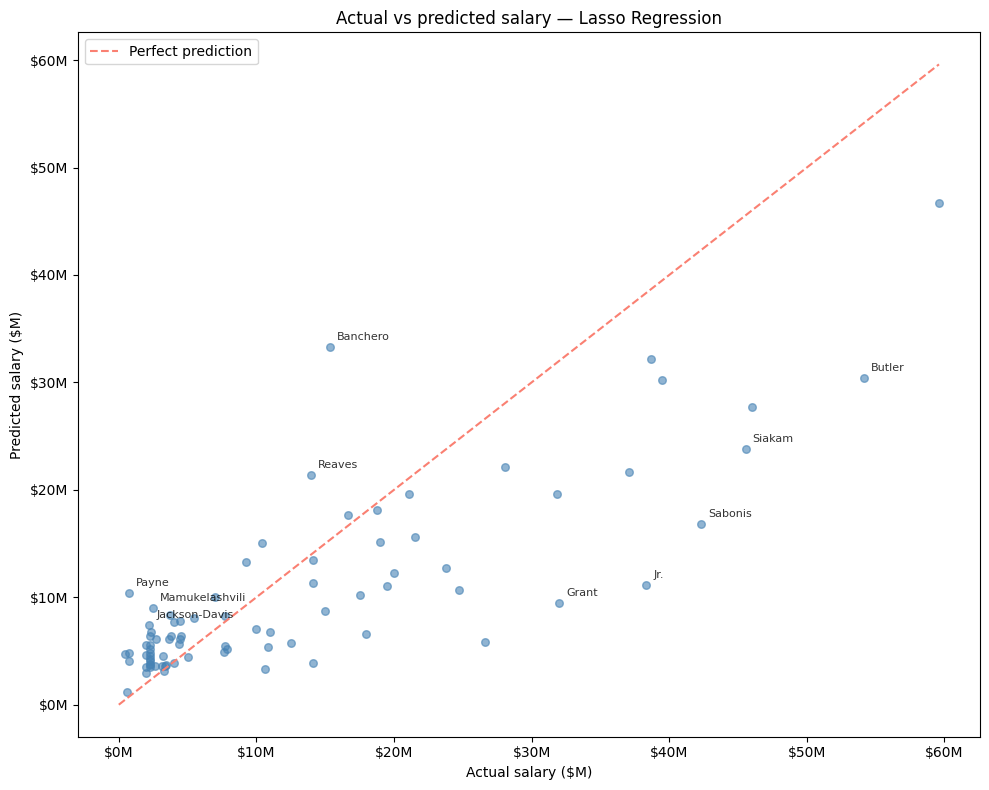

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(test_actual_usd / 1e6, test_pred_usd / 1e6,
           alpha=0.6, color='steelblue', s=30)


max_val = max(test_actual_usd.max(), test_pred_usd.max()) / 1e6
ax.plot([0, max_val], [0, max_val], 
        color='salmon', linewidth=1.5, 
        linestyle='--', label='Perfect prediction')


test_df = pd.DataFrame({
    'actual': test_actual_usd,
    'predicted': test_pred_usd,
    'residual': residuals
}, index=X_test.index)

test_df = test_df.join(player_info[['Player']])


top5_over  = test_df.nlargest(5, 'residual')
top5_under = test_df.nsmallest(5, 'residual')

for _, row in pd.concat([top5_over, top5_under]).iterrows():
    ax.annotate(row['Player'].split()[-1],
                (row['actual'] / 1e6, row['predicted'] / 1e6),
                fontsize=8, alpha=0.8,
                xytext=(5, 5), textcoords='offset points')

ax.set_title('Actual vs predicted salary — Lasso Regression')
ax.set_xlabel('Actual salary ($M)')
ax.set_ylabel('Predicted salary ($M)')
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'${y:.0f}M'))
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/09_actual_vs_predicted.png')
plt.show()

## Finding — actual vs predicted salary

Points below the dashed line = model overpredicts (thinks player 
should earn more than they do)
Points above the dashed line = model underpredicts (player earns 
more than stats suggest)

Key observations:
- Low salary players ($0-10M): tight cluster near the line — 
  model predicts rotation players well
- Mid salary players ($10-30M): reasonable spread, model 
  generally tracks the trend
- High salary players ($30M+): all points fall well below 
  the line — model consistently underpredicts max contracts

Notable players:
- Butler ($54M actual, ~$31M predicted): $23M gap — 
  stats don't justify the contract
- Siakam ($45M actual, ~$24M predicted): $21M gap
- Sabonis ($18M actual, ~$17M predicted): well predicted
- Banchero ($14M actual, ~$33M predicted): model thinks 
  he should earn significantly more — undervalued contract
- Reaves ($13M actual, ~$22M predicted): model sees more 
  value than his contract reflects

The systematic underprediction of max contracts is expected —
these players were signed on reputation and market timing, 
not just current stats.

## Visual 3: Most over and underpaid players
Based on model predictions vs actual salary

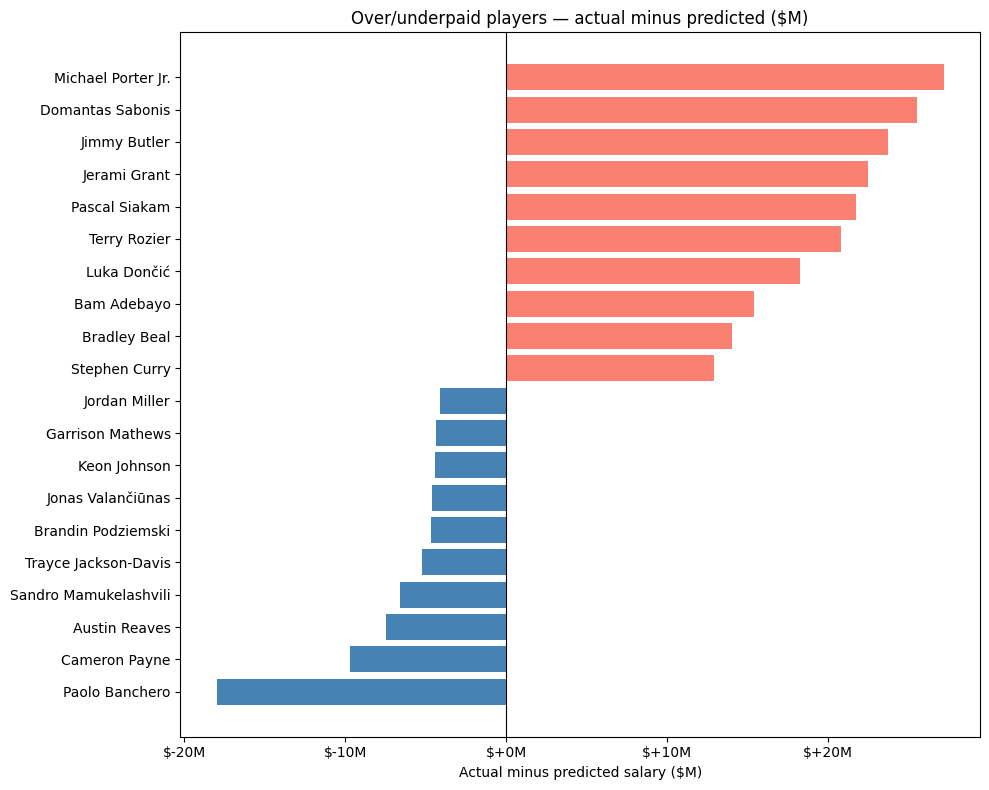

Top 5 overpaid (earning more than stats predict):
                 Player  actual  predicted   gap
17   Michael Porter Jr.    38.3       11.1  27.2
31     Domantas Sabonis    42.3       16.8  25.5
373        Jimmy Butler    54.1       30.4  23.7
154        Jerami Grant    32.0        9.5  22.5
23        Pascal Siakam    45.6       23.8  21.7

Top 5 underpaid (earning less than stats predict):
                    Player  actual  predicted   gap
146         Paolo Banchero    15.3       33.3 -18.0
222          Cameron Payne     0.7       10.4  -9.7
21           Austin Reaves    13.9       21.4  -7.5
277  Sandro Mamukelashvili     2.5        9.0  -6.6
236   Trayce Jackson-Davis     2.2        7.4  -5.2


In [11]:
test_df = pd.DataFrame({
    'actual':    test_actual_usd.values,
    'predicted': test_pred_usd,
    'residual':  residuals.values
}, index=X_test.index).join(player_info[['Player']])

test_df['gap'] = test_df['actual'] - test_df['predicted']

overpaid  = test_df.nlargest(10, 'gap')
underpaid = test_df.nsmallest(10, 'gap')
combined  = pd.concat([overpaid, underpaid]).sort_values('gap')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['salmon' if g > 0 else 'steelblue' for g in combined['gap']]
ax.barh(combined['Player'], combined['gap'] / 1e6, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Over/underpaid players — actual minus predicted ($M)')
ax.set_xlabel('Actual minus predicted salary ($M)')
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:+.0f}M'))

plt.tight_layout()
plt.savefig('../outputs/10_over_underpaid.png')
plt.show()

print("Top 5 overpaid (earning more than stats predict):")
print(overpaid[['Player', 'actual', 'predicted', 'gap']]\
      .head(5)\
      .assign(actual=lambda x: x['actual']/1e6,
              predicted=lambda x: x['predicted']/1e6,
              gap=lambda x: x['gap']/1e6)\
      .round(1)\
      .to_string())

print("\nTop 5 underpaid (earning less than stats predict):")
print(underpaid[['Player', 'actual', 'predicted', 'gap']]\
      .head(5)\
      .assign(actual=lambda x: x['actual']/1e6,
              predicted=lambda x: x['predicted']/1e6,
              gap=lambda x: x['gap']/1e6)\
      .round(1)\
      .to_string())

## Finding — over and underpaid players

Most overpaid vs stats (salmon — earning more than predicted):
- Michael Porter Jr.: +$28M — injury history player on max deal,
  limited games hurt his per 100 stats
- Domantas Sabonis: +$27M — stats are solid but contract reflects 
  his value as a franchise cornerstone more than box score
- Jimmy Butler: +$26M — playoff performer whose regular season 
  stats underrepresent his actual value
- Jerami Grant: +$24M — signed at peak value, production has 
  not matched contract expectations
- Luka Dončić: +$18M — surprising given his talent, but per 100 
  stats are moderate due to high usage and turnovers

Most underpaid vs stats (blue — earning less than predicted):
- Paolo Banchero: -$19M — most underpaid player in test set.
  Elite stats on a rookie scale contract — his next deal will 
  correct this dramatically
- Cameron Payne: -$11M — model sees significant value in his 
  efficiency metrics relative to his minimum wage contract
- Austin Reaves: -$9M — breakout player whose contract predates 
  his emergence as a starter
- Sandro Mamukelashvili: -$8M — efficient per 100 stats on 
  a minimum contract

Key insight: The most underpaid players are young stars on 
rookie contracts (Banchero, Reaves) — exactly what NBA teams 
look for when building competitive rosters on a budget.

## Visual 4: SHAP feature importance
Which stats drive salary predictions most?

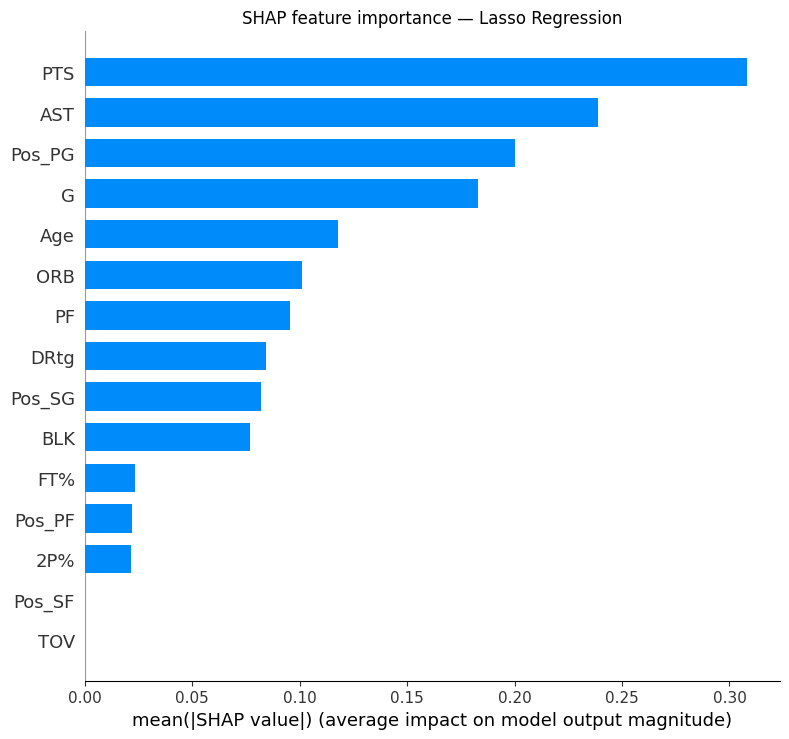

In [12]:
explainer   = shap.LinearExplainer(lasso, X_train)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test,
                  plot_type='bar',
                  max_display=15,
                  show=False)
plt.title('SHAP feature importance — Lasso Regression')
plt.tight_layout()
plt.savefig('../outputs/11_shap_importance.png', bbox_inches='tight')
plt.show()

## Finding — SHAP feature importance

Top features driving salary predictions:

1. PTS (0.31) — scoring is the most rewarded skill by far.
   Points per 100 possessions is the single strongest predictor
   of NBA salary.

2. AST (0.24) — playmaking is the second most valued skill.
   Elite point guards and playmakers command premium contracts.

3. Pos_PG (0.20) — being a point guard carries a significant 
   salary premium independent of stats. The position itself 
   is valued.

4. G (0.19) — games played is the fourth strongest predictor.
   Availability and durability are explicitly priced into contracts.

5. Age (0.12) — age significantly affects salary. Teams pay 
   for prime years and discount older players regardless of 
   current production.

6. ORB (0.10) — offensive rebounding is more valued than 
   defensive rebounding — creates extra possessions.

Notable findings:
- Pos_SF and TOV were zeroed out by Lasso — confirmed as 
  having no independent salary signal
- DRtg (0.09) — defensive rating has moderate importance,
  defense is valued but less than offense
- BLK (0.08) — shot blocking carries some salary signal,
  likely correlated with interior presence

Confirmed EDA finding: The NBA pays for scoring, playmaking, 
availability and position — not shooting efficiency (FT%, 2P% 
near bottom) or turnovers (zeroed out).

## Evaluation summary

Model: Lasso Regression (alpha=0.01)
Test R²:   0.544 — explains 54% of salary variance
Test RMSE: $8.7M — average prediction error

Key findings:
1. Scoring (PTS) and playmaking (AST) drive salary most
2. Position matters — point guards earn a premium
3. Availability (G) and age are explicitly priced in
4. Max contract players are systematically underpredicted —
   reputation and market timing cannot be captured by stats
5. Young stars on rookie deals (Banchero, Reaves) are the 
   most statistically underpaid players

Model limitations:
- Cannot capture contract timing or market dynamics
- Playoff performance and leadership are unquantified
- Sample size of 410 players limits tree-based model performance
- The $8.7M RMSE reflects irreducible error in a stat-only model

What I would do differently:
- Add years remaining on contract as a feature
- Include playoff stats separately — regular season undersells 
  some players
- Collect market size data — large market teams may overpay
- Build separate models by position — salary drivers differ 
  significantly between guards and big men